# Mix energetico in Europa: nucleare, rinnovabili e fossili

Analizzo come è cambiato il mix di produzione elettrica nei paesi europei tra il 1990 e il 2025, concentrandomi sul confronto tra nucleare, rinnovabili e fossili.

## 1. Fonte dei dati

I dati provengono dall’**Energy Dataset** di [Our World in Data](https://github.com/owid/energy-data), che mette insieme dati da diverse fonti istituzionali, soprattutto **Ember** (dati elettrici annuali, copertura sistematica dal 1990 per i paesi europei) ed **Energy Institute** (Statistical Review of World Energy, serie storiche più lunghe). È aggiornato al 2026 e rilasciato con licenza CC BY.

> Ember (2026); Energy Institute - Statistical Review of World Energy (2025) — with major processing by Our World in Data.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd()
df = pd.read_csv(DATA_DIR / "data" / "owid-energy-data.csv")

print(df.shape)
df.head()

(23377, 130)


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [2]:
codebook = pd.read_csv(DATA_DIR / "data" / "owid-energy-codebook.csv")

print(codebook.shape)
codebook.head()

(130, 5)


,column,title,description,unit,source
0,country,Country,Geographic location.,NaN,Our World in Data - Regions (2025)
1,year,Year,Year of observation.,NaN,Our World in Data - Regions (2025)
2,iso_code,ISO code,ISO 3166-1 alpha-3 three-letter country codes.,NaN,International Organization for Standardization...
3,population,Population,"Population by country, available from 10,000 B...",people,Population based on various sources (2024) [ht...
4,gdp,Gross domestic product (GDP),Total economic output of a country or region p...,international-$ in 2011 prices ($),Bolt and van Zanden – Maddison Project Databas...


## 2. Struttura del dataset

Formato long: una riga per ogni combinazione paese-anno, 130 colonne diverse. Oltre ai paesi veri e propri ci sono anche aggregati (continenti, gruppi economici) costruiti da OWID.

In [3]:
print(f"Righe: {df.shape[0]:,}")
print(f"Colonne: {df.shape[1]}")
print(f"Periodo: {df['year'].min()} - {df['year'].max()}")
print(f"Entità (paesi + aggregati): {df['country'].nunique()}")


Righe: 23,377
Colonne: 130
Periodo: 1900 - 2025
Entità (paesi + aggregati): 314


La colonna `country` contiene anche gli aggregati (continenti, "World", "EU (Ember)", "G7 (Ember)", ecc.), riconoscibili perché non hanno `iso_code`. Da qui in avanti lavoro solo sui paesi con un codice ISO valido.

In [4]:
# Quante "entità" non sono paesi veri (non hanno iso_code)?
aggregati = sorted(df.loc[df["iso_code"].isna(), "country"].unique())
print(f"Aggregati/non-paesi individuati: {len(aggregati)}")
aggregati[:15]  # primi esempi


Aggregati/non-paesi individuati: 94


['ASEAN (Ember)',
 'Africa',
 'Africa (EI)',
 'Africa (EIA)',
 'Africa (Ember)',
 'Africa (Shift)',
 'Asia',
 'Asia (Ember)',
 'Asia Pacific (EI)',
 'Asia and Oceania (EIA)',
 'Asia and Oceania (Shift)',
 'Australia and New Zealand (EIA)',
 'CIS (EI)',
 'Central America (EI)',
 'Central and South America (EIA)']

## 3. Analisi dei valori mancanti

Ci sono parecchi NaN nel dataset, e prima di fare qualsiasi grafico voglio capire se sono casuali o se seguono uno schema preciso.

Per ogni paese e ogni variabile chiave classifico il pattern in quattro categorie: `complete`, `left-censored` (NaN solo prima del primo anno rilevato), `internal-gaps` (buchi in mezzo alla serie) e `always-null` (dato mai disponibile). Lo faccio separatamente per Europa e resto del mondo, perché mi aspetto che la qualità dei dati sia diversa.

In [5]:
EUROPE_ISO = {
    "ALB", "AND", "AUT", "BLR", "BEL", "BIH", "BGR", "HRV", "CYP", "CZE",
    "DNK", "EST", "FIN", "FRA", "DEU", "GRC", "HUN", "ISL", "IRL", "ITA",
    "XKX", "LVA", "LIE", "LTU", "LUX", "MLT", "MDA", "MCO", "MNE", "NLD",
    "MKD", "NOR", "POL", "PRT", "ROU", "RUS", "SMR", "SRB", "SVK", "SVN",
    "ESP", "SWE", "CHE", "UKR", "GBR", "VAT",
}

KEY_COLS = [
    "electricity_generation",
    "fossil_electricity",
    "nuclear_electricity",
    "renewables_electricity",
    "solar_electricity",
    "wind_electricity",
    "hydro_electricity",
]

df_eu = df[df["iso_code"].isin(EUROPE_ISO)].copy()
print(f"Paesi europei nel dataset: {df_eu['country'].nunique()}")
print(f"Righe totali: {len(df_eu):,}  |  Anni: {df_eu['year'].min()}–{df_eu['year'].max()}")

Paesi europei nel dataset: 40
Righe totali: 3,488  |  Anni: 1900–2025


In [6]:
def classify_missing(series: pd.Series) -> dict:
    first_idx = series.first_valid_index()
    if first_idx is None:
        return {"first_valid": None, "nan_before": int(series.isna().sum()), "nan_after": 0, "pattern": "always-null"}
    nan_before = int(series.loc[:first_idx].iloc[:-1].isna().sum())
    nan_after  = int(series.loc[first_idx:].isna().sum())
    if nan_after == 0:
        pattern = "complete" if nan_before == 0 else "left-censored"
    else:
        pattern = "internal-gaps"
    return {"first_valid": first_idx, "nan_before": nan_before, "nan_after": nan_after, "pattern": pattern}


def gap_ranges(s: pd.Series, first_idx) -> str | None:
    """Restituisce gli anni NaN dopo first_idx come stringa di intervalli, o None se assenti."""
    gap_years = s.loc[first_idx:][s.loc[first_idx:].isna()].index.tolist()
    if not gap_years:
        return None
    ranges, start, prev = [], gap_years[0], gap_years[0]
    for y in gap_years[1:]:
        if y == prev + 1:
            prev = y
        else:
            ranges.append(f"{start}–{prev}" if start != prev else str(start))
            start = prev = y
    ranges.append(f"{start}–{prev}" if start != prev else str(start))
    return ", ".join(ranges)


def build_miss(df_subset: pd.DataFrame) -> pd.DataFrame:
    """Classifica il pattern dei missing values per ogni coppia paese × colonna chiave."""
    records = []
    for country, grp in df_subset.groupby("country"):
        grp_sorted = grp.sort_values("year").set_index("year")
        for col in KEY_COLS:
            if col in grp_sorted.columns:
                records.append({"country": country, "column": col, **classify_missing(grp_sorted[col])})
    return pd.DataFrame(records)


miss = build_miss(df_eu)

### 3.1 Copertura temporale dei paesi europei

In [7]:
print("=== Distribuzione dei pattern — Europa (paese × colonna) ===")
print(miss["pattern"].value_counts().to_string())

print("\n=== Anno del primo dato valido ===")
pivot = miss[miss["pattern"] != "always-null"].pivot(
    index="country", columns="column", values="first_valid"
).astype("Int64")
print(pivot.to_string())

print("\n=== Gap interni ===")
for country, grp in df_eu.groupby("country"):
    grp_sorted = grp.sort_values("year").set_index("year")
    for col in KEY_COLS:
        if col not in grp_sorted.columns:
            continue
        s = grp_sorted[col]
        first_idx = s.first_valid_index()
        if first_idx is None:
            continue
        r = gap_ranges(s, first_idx)
        if r:
            print(f"  {country:30s}  {col:30s}  {r}")

=== Distribuzione dei pattern — Europa (paese × colonna) ===
pattern
left-censored    174
complete          86
internal-gaps     20

=== Anno del primo dato valido ===
column                  electricity_generation  fossil_electricity  hydro_electricity  nuclear_electricity  renewables_electricity  solar_electricity  wind_electricity
country                                                                                                                                                                
Albania                                   2000                2000               2000                 2000                    2000               2000              2000
Austria                                   1985                1990               1965                 1965                    1965               1965              1965
Belarus                                   1985                2000               1985                 1985                    1985               1985           

  Estonia                         wind_electricity                2000–2001
  Hungary                         wind_electricity                2000


  Lithuania                       wind_electricity                2000–2003


  Malta                           wind_electricity                2000–2011
  North Macedonia                 wind_electricity                2000–2013


  Romania                         wind_electricity                2000–2004
  Serbia                          wind_electricity                2000–2011
  Slovakia                        wind_electricity                2000–2002
  Slovenia                        wind_electricity                2000–2012
  Ukraine                         electricity_generation          2023–2024
  Ukraine                         fossil_electricity              2023–2024
  Ukraine                         nuclear_electricity             2023–2024
  Ukraine                         renewables_electricity          2023–2024
  Ukraine                         solar_electricity               2023–2024
  Ukraine                         wind_electricity                2023–2024
  Ukraine                         hydro_electricity               2023–2024


**Europa: copertura**

Il pattern più comune è il left-censoring (174 coppie paese-colonna), il 71% di queste serie parte prima, con mediana al 1965. Il 1990 come soglia vale soprattutto per `fossil_electricity`: per le altre variabili chiave (nucleare, rinnovabili, solare, eolico, idroelettrico) 25 dei 40 paesi europei hanno dati già dal 1965, grazie alle serie storiche dell’Energy Institute. Non è un’eccezione di poche grandi economie ma è la norma per gran parte dell’Europa occidentale e del nord. `electricity_generation` (il totale) fa eccezione e segue invece `fossil_electricity`: nessun paese europeo ha un dato di generazione totale prima del 1985 (guardo il perché nel 3.4). Il 1990 riguarda soprattutto gli ex paesi sovietici e jugoslavi (dati dal 1985 o dal 1990) e chi è entrato più tardi nella rilevazione (Albania, Bosnia, Moldova dal 2000; Montenegro dal 2005).

I gap interni sono concentrati sugli stati successori dell’URSS e della Jugoslavia, con discontinuità tipicamente tra il 1990 e il 1993. I microstati (Andorra, Monaco, Liechtenstein, San Marino, Vaticano) hanno always-null su colonne come `nuclear_electricity`, semplicemente perché non hanno centrali nucleari.

### 3.2 Copertura nel resto del mondo

In [8]:
df_world = df[df["iso_code"].notna() & ~df["iso_code"].isin(EUROPE_ISO)].copy()
print(f"Paesi non europei nel dataset: {df_world['country'].nunique()}")

miss_w = build_miss(df_world)

print("\n=== Distribuzione dei pattern — Resto del mondo (paese × colonna) ===")
print(miss_w["pattern"].value_counts().to_string())

print("\n=== Anno del primo dato valido ===")
pivot_w = miss_w[miss_w["pattern"] != "always-null"].pivot(
    index="country", columns="column", values="first_valid"
).astype("Int64")
print(pivot_w.to_string())

print("\n=== Gap interni ===")
found_any = False
for country, grp in df_world.groupby("country"):
    grp_sorted = grp.sort_values("year").set_index("year")
    for col in KEY_COLS:
        if col not in grp_sorted.columns:
            continue
        s = grp_sorted[col]
        first_idx = s.first_valid_index()
        if first_idx is None:
            continue
        r = gap_ranges(s, first_idx)
        if r:
            found_any = True
            print(f"  {country:40s}  {col:30s}  {r}")
if not found_any:
    print("  Nessun gap interno.")

print("\n=== Casi always-null ===")
always_null_w = miss_w[miss_w["pattern"] == "always-null"][["country", "column"]]
print(always_null_w.sort_values(["country", "column"]).to_string(index=False))

Paesi non europei nel dataset: 180



=== Distribuzione dei pattern — Resto del mondo (paese × colonna) ===
pattern
left-censored    1139
complete           53
always-null        50
internal-gaps      18

=== Anno del primo dato valido ===
column                            electricity_generation  fossil_electricity  hydro_electricity  nuclear_electricity  renewables_electricity  solar_electricity  wind_electricity
country                                                                                                                                                                          
Afghanistan                                         2000                2000               2000                 2000                    2000               2000              2000
Algeria                                             1985                2000               1965                 1965                    1965               1965              1965
American Samoa                                      2000                2000         

  Saudi Arabia                              hydro_electricity               2000–2024
  Singapore                                 nuclear_electricity             2025
  Singapore                                 wind_electricity                2000–2025
  Singapore                                 hydro_electricity               2000–2025
  Sri Lanka                                 nuclear_electricity             2025
  Thailand                                  nuclear_electricity             2025
  United Arab Emirates                      hydro_electricity               2000–2024
  Western Sahara                            electricity_generation          2010–2023
  Western Sahara                            fossil_electricity              2010–2023
  Western Sahara                            nuclear_electricity             2010–2023
  Western Sahara                            renewables_electricity          2010–2023
  Western Sahara                            solar_electricity        

**Resto del mondo: copertura**

Qui la copertura è molto più disomogenea. Le grandi economie (Stati Uniti, Cina, India, Giappone, Brasile, Australia) hanno serie complete, paragonabili a quelle europee. Per il resto del campione la qualità scende via via con la dimensione economica e la capacità statistica del paese.

La differenza vera rispetto all’Europa è quanto pesano gli `always-null`: variabili mai rilevate per interi paesi, soprattutto piccoli stati insulari, paesi in via di sviluppo e paesi con conflitti prolungati. Conferma che Ember copre l’Europa in modo sistematico, ma nel resto del mondo è più selettivo.

In [9]:
LAST_YEAR = df["year"].max()  # 2025

def right_censored(group, col):
    """Restituisce l'ultimo anno con dato valido per una colonna, o None se sempre NaN."""
    s = group.sort_values("year").set_index("year")[col]
    last_idx = s.last_valid_index()
    return last_idx

# --- Europa ---
rc_eu = []
for country, grp in df_eu.groupby("country"):
    for col in KEY_COLS:
        if col not in grp.columns:
            continue
        last = right_censored(grp, col)
        if last is not None and last < LAST_YEAR:
            rc_eu.append({"country": country, "column": col, "last_valid": last, "missing_tail": LAST_YEAR - last})

rc_eu_df = pd.DataFrame(rc_eu).sort_values("missing_tail", ascending=False)

# --- Resto del mondo ---
rc_w = []
for country, grp in df_world.groupby("country"):
    for col in KEY_COLS:
        if col not in grp.columns:
            continue
        last = right_censored(grp, col)
        if last is not None and last < LAST_YEAR:
            rc_w.append({"country": country, "column": col, "last_valid": last, "missing_tail": LAST_YEAR - last})

rc_w_df = pd.DataFrame(rc_w).sort_values("missing_tail", ascending=False)

print(f"=== Right-censoring: EUROPA ({len(rc_eu_df)} coppie paese×colonna con serie troncata prima del {LAST_YEAR}) ===")
if rc_eu_df.empty:
    print("  Nessun caso.")
else:
    print(rc_eu_df.to_string(index=False))

print(f"\n=== Right-censoring: RESTO DEL MONDO ({len(rc_w_df)} coppie paese×colonna con serie troncata prima del {LAST_YEAR}) ===")
if rc_w_df.empty:
    print("  Nessun caso.")
else:
    print(rc_w_df.to_string(index=False))

=== Right-censoring: EUROPA (21 coppie paese×colonna con serie troncata prima del 2025) ===
country                 column  last_valid  missing_tail
Ukraine     fossil_electricity        2022             3
Ukraine       wind_electricity        2022             3
Ukraine      solar_electricity        2022             3
Ukraine      hydro_electricity        2022             3
Ukraine renewables_electricity        2022             3
Ukraine electricity_generation        2022             3
Ukraine    nuclear_electricity        2022             3
Albania      solar_electricity        2024             1
Albania     fossil_electricity        2024             1
Albania electricity_generation        2024             1
Albania renewables_electricity        2024             1
Albania    nuclear_electricity        2024             1
Albania       wind_electricity        2024             1
Iceland       wind_electricity        2024             1
Iceland      solar_electricity        2024           

### 3.3 Sintesi e implicazioni

I NaN non sono casuali: quattro pattern strutturali spiegano quasi tutto.

**Left-censoring**: ogni paese entra nel dataset quando parte la rilevazione sistematica. I NaN prima non sono dati persi, è che la fonte non c’era ancora.

**Gap interni**: legati a discontinuità istituzionali note (fine URSS, fine Jugoslavia, conflitti). Il buco segue la frattura storica, non la variabile.

**Always-null**: quasi solo fuori Europa, dove la copertura dipende dalla capacità statistica del paese. In Europa è un caso marginale.

**Right-censoring**: 21 coppie paese-colonna in Europa (Ucraina ferma al 2022 per l’interruzione della rilevazione dopo l’invasione russa; Albania e Islanda ferme al 2024) e ben 851 nel resto del mondo, su 128 dei 180 paesi non europei. Nella maggior parte dei casi (733 su 851) è solo un anno di ritardo di pubblicazione; una minoranza ha code più lunghe: Singapore, Arabia Saudita ed Emirati Arabi Uniti non riportano più `hydro_electricity` dal 1999, il Sahara Occidentale non ha dati dopo il 2009. Anche qui la causa è strutturale: ritardo di pubblicazione o una variabile che non viene più rilevata perché non rilevante per quel paese.

Nessuno di questi pattern mi sembra da correggere con un’imputazione. Meglio lavorare sul sottoinsieme dove i dati ci sono davvero: per l’Europa, a partire dagli anni ’90.

### 3.4 Le firme storiche nei dati: la censura a sinistra come indicatore geopolitico

`electricity_generation` non ha nessun gap interno in Europa: una volta partita, la serie di ogni paese resta valida fino all’ultimo anno disponibile (l’unica eccezione è il right-censoring dell’Ucraina dal 2023, già visto in 3.3, una coda mancante, non un buco). Quindi il "dato mancante" interessante per questa colonna non è un buco a metà serie, ma la data di inizio, che cambia da paese a paese. Mi chiedo se queste date siano sparse a caso o se si raggruppino in qualche modo.

In [10]:
recs = []
for country, grp in df_eu.groupby("country"):
    g = grp.sort_values("year").set_index("year")["electricity_generation"]
    fvi = g.first_valid_index()
    if fvi is None:
        continue
    lvi = g.last_valid_index()
    interior_gaps = int(g.loc[fvi:lvi].isna().sum())
    recs.append({"country": country, "first_valid": fvi, "interior_gaps": interior_gaps})

fv = pd.DataFrame(recs).sort_values("first_valid")
print(f"Paesi con gap interno vero (non solo coda mancante): {(fv['interior_gaps'] > 0).sum()} / {len(fv)}")
print("\n=== Anno del primo dato di electricity_generation, per soglia ===")
print(fv["first_valid"].value_counts().sort_index().to_string())
print("\n=== Paesi che NON iniziano nel 1985 (le uniche eccezioni) ===")
print(fv[fv["first_valid"] > 1985].sort_values("first_valid").to_string(index=False))

Paesi con gap interno vero (non solo coda mancante): 0 / 40

=== Anno del primo dato di electricity_generation, per soglia ===
first_valid
1985    31
1990     5
2000     3
2005     1

=== Paesi che NON iniziano nel 1985 (le uniche eccezioni) ===
               country  first_valid  interior_gaps
       North Macedonia         1990              0
                 Malta         1990              0
               Croatia         1990              0
              Slovenia         1990              0
                Serbia         1990              0
Bosnia and Herzegovina         2000              0
               Moldova         2000              0
               Albania         2000              0
            Montenegro         2005              0


Confermato: **zero gap interni**. Le date di inizio si raggruppano in quattro soglie nette:

- **1985**: 31 dei 40 paesi, praticamente tutto il continente: non solo Russia, Ucraina, i tre Baltici, Bielorussia, Cechia e Slovacchia, ma anche Francia, Germania, Italia, Regno Unito, Spagna e il resto dell’Europa occidentale. Non è una soglia specifica del blocco post-sovietico: è semplicemente da quando l’Energy Institute inizia a pubblicare `electricity_generation` per tutto il continente (da non confondere con le altre variabili chiave del 3.1, che per 25 paesi arrivano fino al 1965: solo il totale e `fossil_electricity` restano bloccati al 1985, probabilmente perché il totale richiede che fossile, nucleare e rinnovabili siano tutti disponibili nello stesso anno).
- **1990**: Macedonia del Nord, Malta, Croazia, Slovenia, Serbia.
- **2000**: Bosnia ed Erzegovina, Moldova, Albania.
- **2005**: Montenegro, unico caso.

La cosa interessante non è il 1985 (che è universale), ma come si scaglionano le soglie successive: seguono abbastanza da vicino la sequenza 1990-2008 della disgregazione jugoslava. Slovenia e Croazia (indipendenza 1991) e Macedonia del Nord (indipendenza pacifica, sempre 1991) partono nel 1990; la Bosnia (guerra 1992-95) parte nel 2000; il Montenegro (indipendenza 2006) parte nel 2005, sempre dopo l’evento politico, mai prima. Due avvertenze però: Malta è nello stesso gruppo del 1990 senza avere niente a che fare con la Jugoslavia (è solo una coincidenza di copertura statistica), e la Moldova (ex URSS, non ex Jugoslavia) condivide la soglia 2000 con Bosnia e Albania: la tabella raggruppa per anno, non per causa comune. È una correlazione suggestiva ma da prendere con le pinze: il tipo di cosa che va verificata bene prima di scriverla in un titolo.

Nota a margine sui nomi: `USSR`, `Yugoslavia` e `Serbia and Montenegro` esistono come entità nel dataset OWID, ma non hanno mai un valore di `electricity_generation`: righe segnaposto, probabilmente popolate per altre variabili (popolazione, PIL) ma non per l’elettricità. La Germania invece è una serie unica e continua dal 1985: esistono voci `East Germany`/`West Germany` nell’elenco dei paesi, ma anche quelle senza dati di generazione: la riunificazione del 1990 non crea nessuna discontinuità visibile nella serie.

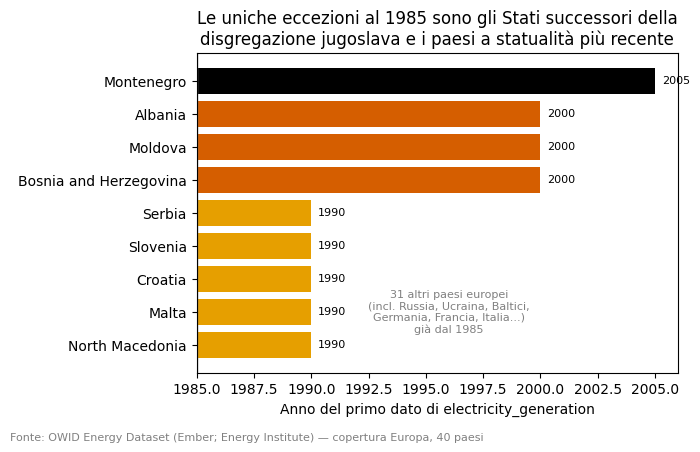

In [11]:
later = fv[fv["first_valid"] > 1985].sort_values("first_valid")
_bucket_color = {1990: "#E69F00", 2000: "#D55E00", 2005: "#000000"}
colors = [_bucket_color[y] for y in later["first_valid"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(later["country"], later["first_valid"] - 1985, left=1985, color=colors)
for country, year in zip(later["country"], later["first_valid"]):
    ax.text(year + 0.3, country, str(year), va="center", fontsize=8)
ax.axvline(1985, color="gray", linewidth=1)
ax.text(1996, 1,
        "31 altri paesi europei\n(incl. Russia, Ucraina, Baltici,\nGermania, Francia, Italia...)\ngià dal 1985",
        fontsize=8, color="gray", va="center", ha="center")
ax.set_xlabel("Anno del primo dato di electricity_generation")
ax.set_title("Le uniche eccezioni al 1985 sono gli Stati successori della\ndisgregazione jugoslava e i paesi a statualità più recente")
fig.text(0.01, 0.01, "Fonte: OWID Energy Dataset (Ember; Energy Institute) — copertura Europa, 40 paesi", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 4. Comporre e confrontare il mix elettrico europeo

Qui provo i grafici del tema centrale del progetto (il confronto tra fossili, nucleare e rinnovabili) prima di portarli in Streamlit. Scelgo ogni grafico in base al task comunicativo (confronto, composizione, evoluzione), non al tipo di dato, evitando gli anti-pattern visti a lezione e usando la gerarchia di Cleveland & McGill per capire quale encoding è più accurato per ogni domanda. I vincoli di copertura visti nel Cap. 3 (panel bilanciato, cutoff 2022) valgono anche qui.

### 4.1 Perché serve un panel bilanciato

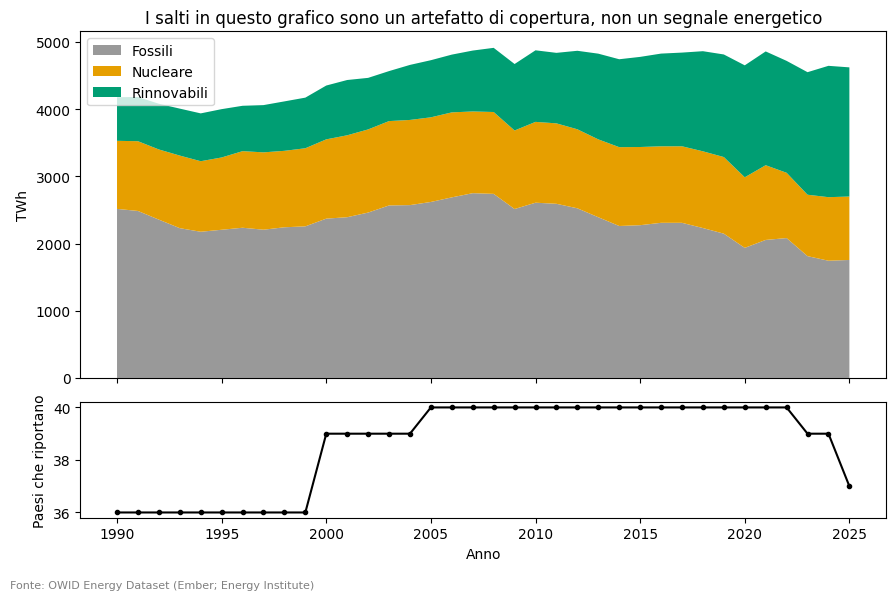

In [12]:
SOURCE_NOTE = "Fonte: OWID Energy Dataset (Ember; Energy Institute)"
PALETTE = {"fossile": "#999999", "nucleare": "#E69F00", "rinnovabili": "#009E73", "calo": "#D55E00"}

agg40 = (
    df_eu[df_eu["year"] >= 1990]
    .groupby("year")[["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]]
    .sum(min_count=1)
)
agg40["n_countries"] = (
    df_eu[df_eu["year"] >= 1990]
    .groupby("year")["electricity_generation"]
    .apply(lambda s: s.notna().sum())
)

# Due assi allineati (small multiples), non un dual axis sullo stesso plot:
# TWh e "numero di paesi" non condividono un'unità, sovrapporli sarebbe l'anti-pattern
# "dual axis" segnalato nel materiale del corso.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, height_ratios=[3, 1])
ax1.stackplot(
    agg40.index,
    agg40["fossil_electricity"], agg40["nuclear_electricity"], agg40["renewables_electricity"],
    labels=["Fossili", "Nucleare", "Rinnovabili"],
    colors=[PALETTE["fossile"], PALETTE["nucleare"], PALETTE["rinnovabili"]],
)
ax1.set_title("I salti in questo grafico sono un artefatto di copertura, non un segnale energetico")
ax1.set_ylabel("TWh")
ax1.legend(loc="upper left")

ax2.plot(agg40.index, agg40["n_countries"], color="black", marker=".")
ax2.set_ylabel("Paesi che riportano")
ax2.set_xlabel("Anno")

fig.text(0.01, 0.01, SOURCE_NOTE, fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

Il pannello sotto mostra la causa: il numero di paesi che contribuiscono alla somma passa da 36 (1990–99) a 39 (dal 2000) a 40 (dal ~2005), per poi scendere a 39 e 37 nel 2023–25 per il right-censoring di Ucraina, Albania e Islanda (visto nel 3.3). Evito apposta il dual axis (l’anti-pattern classico: due unità diverse sullo stesso grafico fanno vedere una correlazione che in realtà non è verificabile) e uso invece due pannelli allineati sulla stessa x: così si vede il salto nella serie e la sua causa senza dover interpretare una sovrapposizione arbitraria.

La soluzione è restringersi a un **panel bilanciato**: solo i paesi con serie completa dal 1990 al 2022 su tutte le variabili chiave.

In [13]:
window = df_eu[(df_eu["year"] >= 1990) & (df_eu["year"] <= 2022)]

complete_countries = [
    country
    for country, grp in window.groupby("country")
    if grp.set_index("year").reindex(range(1990, 2023))[
        ["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]
    ].notna().all().all()
]
excluded = sorted(set(df_eu["country"].unique()) - set(complete_countries))
print(f"Paesi con serie completa 1990-2022: {len(complete_countries)} / {df_eu['country'].nunique()}")
print(f"Esclusi: {excluded}")

bal_all = window[window["country"].isin(complete_countries)]

# Quanto pesa l'esclusione? Confronto 2020, con e senza i due paesi esclusi più "estremi"
# (Svizzera: nucleare+idro quasi senza fossile; Islanda: 100% rinnovabile).
y = 2020
full40_y = df_eu[df_eu["year"] == y]
bal33_y = full40_y[full40_y["country"].isin(complete_countries)]

print("\n=== Quota sul totale europeo (media pesata per generazione, 2020) ===")
for label, d in [("40 paesi", full40_y), ("33 paesi (panel bilanciato)", bal33_y)]:
    tot = d["electricity_generation"].sum()
    shares = {k: d[f"{k}_electricity"].sum() / tot * 100 for k in ["fossil", "nuclear", "renewables"]}
    print(f"  {label}: {shares}")

print("\n=== Quota media per paese, non pesata (2020) ===")
for label, d in [("40 paesi", full40_y), ("33 paesi (panel bilanciato)", bal33_y)]:
    m = d[["fossil_share_elec", "nuclear_share_elec", "renewables_share_elec"]].mean()
    print(f"  {label}: {m.round(1).to_dict()}")

Paesi con serie completa 1990-2022: 33 / 40
Esclusi: ['Albania', 'Belarus', 'Bosnia and Herzegovina', 'Iceland', 'Moldova', 'Montenegro', 'Switzerland']

=== Quota sul totale europeo (media pesata per generazione, 2020) ===
  40 paesi: {'fossil': np.float64(41.610908681279476), 'nuclear': np.float64(22.580325781701056), 'renewables': np.float64(35.80876545692362)}
  33 paesi (panel bilanciato): {'fossil': np.float64(41.778459455718284), 'nuclear': np.float64(22.830169847444516), 'renewables': np.float64(35.39137064908388)}

=== Quota media per paese, non pesata (2020) ===
  40 paesi: {'fossil_share_elec': 43.0, 'nuclear_share_elec': 14.2, 'renewables_share_elec': 42.8}
  33 paesi (panel bilanciato): {'fossil_share_elec': 42.7, 'nuclear_share_elec': 16.1, 'renewables_share_elec': 41.2}


I 7 paesi esclusi (Albania, Bielorussia, Bosnia ed Erzegovina, Islanda, Moldova, Montenegro, Svizzera) includono due casi estremi: la Svizzera (nucleare + idro, quasi zero fossile) e l’Islanda (100% rinnovabile/geotermico). Escluderli non è del tutto innocuo, ma quanto pesa dipende da come si aggrega: sulla quota europea pesata per generazione la differenza è minima (nucleare 22.6% → 22.8%, rinnovabili 35.8% → 35.4%: sono economie piccole, pesano poco sulla somma assoluta). Sulla media semplice per paese invece si vede di più (nucleare 14.2% → 16.1%, rinnovabili 42.8% → 41.2%): lì ogni paese conta uguale, e togliere due profili estremi sposta la media di qualche punto. Per l’andamento aggregato europeo uso quindi il panel bilanciato con somme pesate (sotto); per i confronti tra paesi, invece, meglio non nascondere mai la selezione.

### 4.2 Composizione vs confronto: stesso dato, due grafici

Lo stacked area risponde alla domanda "di cosa è fatto il totale" (composizione). Ma la domanda che mi interessa davvero è un confronto tra tre andamenti nel tempo, e per quello l’encoding più accurato secondo Cleveland & McGill è la posizione su una scala comune (una linea per fonte, stesso asse 0–100%), non lo spessore di bande impilate su basi che cambiano. Li metto affiancati per vedere la differenza.

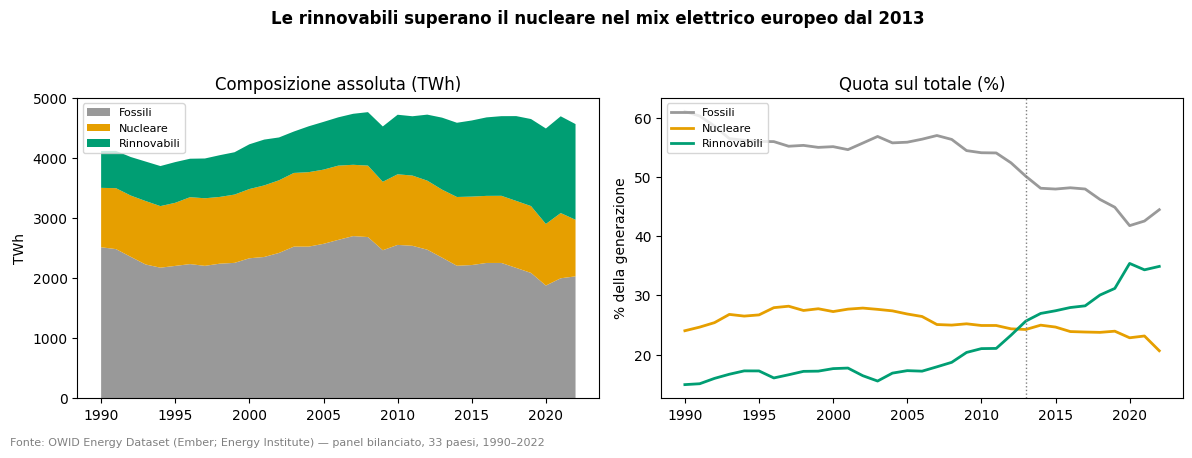

In [14]:
agg_bal = (
    bal_all.groupby("year")[["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]]
    .sum()
)
agg_bal_share = agg_bal.div(agg_bal["electricity_generation"], axis=0) * 100

crossover = agg_bal_share[agg_bal_share["renewables_electricity"] > agg_bal_share["nuclear_electricity"]].index.min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].stackplot(
    agg_bal.index,
    agg_bal["fossil_electricity"], agg_bal["nuclear_electricity"], agg_bal["renewables_electricity"],
    labels=["Fossili", "Nucleare", "Rinnovabili"],
    colors=[PALETTE["fossile"], PALETTE["nucleare"], PALETTE["rinnovabili"]],
)
axes[0].set_title("Composizione assoluta (TWh)")
axes[0].set_ylabel("TWh")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].plot(agg_bal_share.index, agg_bal_share["fossil_electricity"], color=PALETTE["fossile"], label="Fossili", linewidth=2)
axes[1].plot(agg_bal_share.index, agg_bal_share["nuclear_electricity"], color=PALETTE["nucleare"], label="Nucleare", linewidth=2)
axes[1].plot(agg_bal_share.index, agg_bal_share["renewables_electricity"], color=PALETTE["rinnovabili"], label="Rinnovabili", linewidth=2)
axes[1].axvline(crossover, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Quota sul totale (%)")
axes[1].set_ylabel("% della generazione")
axes[1].legend(loc="upper left", fontsize=8)

fig.suptitle(f"Le rinnovabili superano il nucleare nel mix elettrico europeo dal {crossover}", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 33 paesi, 1990–2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

Il pannello di sinistra (composizione) mostra che il totale generato cresce e che i fossili restano il blocco più grande in volume. Quello di destra (confronto) mostra invece quello che lo stacked area nasconde: le rinnovabili superano stabilmente il nucleare a partire dal 2013 (nel 1990 il nucleare era al 24.0% contro il 14.9% delle rinnovabili; nel 2022 il rapporto si è ribaltato, 20.6% contro 34.9%). I fossili scendono dal 61.1% al 44.5% ma restano comunque maggioritari. Nessuna delle due letture è sbagliata, rispondono solo a domande diverse: per questo nella dashboard il tipo di grafico dovrebbe seguire il task scelto dall’utente, non essere fisso.

### 4.2.1 Quante fonti prima che lo stacked area diventi illeggibile?

Lo provo sulla Germania (fossile in calo, nucleare in uscita e più fonti rinnovabili in crescita insieme: il mix con più bande in movimento nello stesso periodo) impilando le stesse 6 quote.

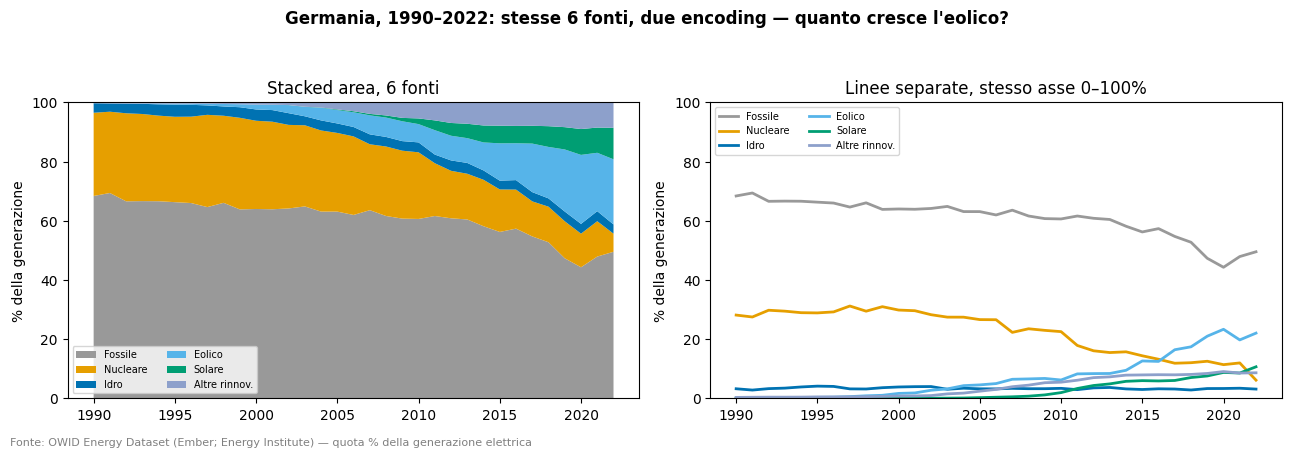

In [15]:
DETAIL_COLORS = {
    "Fossile": PALETTE["fossile"], "Nucleare": PALETTE["nucleare"],
    "Idro": "#0072B2", "Eolico": "#56B4E9", "Solare": "#009E73", "Altre rinnov.": "#8DA0CB",
}
detail_cols = ["fossil_share_elec", "nuclear_share_elec", "hydro_share_elec",
               "wind_share_elec", "solar_share_elec", "other_renewables_share_elec"]
detail_labels = list(DETAIL_COLORS.keys())

d_de = bal_all[bal_all["country"] == "Germany"].sort_values("year").set_index("year")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].stackplot(
    d_de.index, *[d_de[c] for c in detail_cols],
    labels=detail_labels, colors=list(DETAIL_COLORS.values()),
)
axes[0].set_title("Stacked area, 6 fonti")
axes[0].set_ylabel("% della generazione")
axes[0].set_ylim(0, 100)
axes[0].legend(loc="lower left", fontsize=7, ncol=2)

for col, label in zip(detail_cols, detail_labels):
    axes[1].plot(d_de.index, d_de[col], color=DETAIL_COLORS[label], label=label, linewidth=2)
axes[1].set_title("Linee separate, stesso asse 0–100%")
axes[1].set_ylabel("% della generazione")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="upper left", fontsize=7, ncol=2)

fig.suptitle("Germania, 1990–2022: stesse 6 fonti, due encoding — quanto cresce l'eolico?", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — quota % della generazione elettrica", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

Nel pannello impilato, la banda Eolico sta sopra fossile+nucleare+idro: la sua base scende da 99.7% (1990) a 58.7% (2022), un salto di 41 punti che non c’entra niente con l’eolico ma con il crollo di fossile e nucleare sotto di lui. Per capire quanto è cresciuto davvero l’eolico (0% → 22.0%) nello stack devo sottrarre mentalmente due bordi che si muovono entrambi nel tempo; nel pannello a linee lo stesso numero si legge direttamente sull’asse. Con 3 fonti (4.2) il problema c’è ma è marginale; con 6 diventa il motivo principale per cui preferisco le linee quando le fonti da confrontare sono tante. Nonostante ciò il pannello impilato resta molto più intuitivo al primo sguardo.

### 4.3 Chi ha trasformato di più il proprio mix?

Qui è un task di confronto puro: un valore per paese, la variazione della quota rinnovabili tra 1990 e 2022. Encoding di conseguenza: bar orizzontale ordinata per valore (non alfabeticamente), colore diverging per far risaltare l’unico caso anomalo.

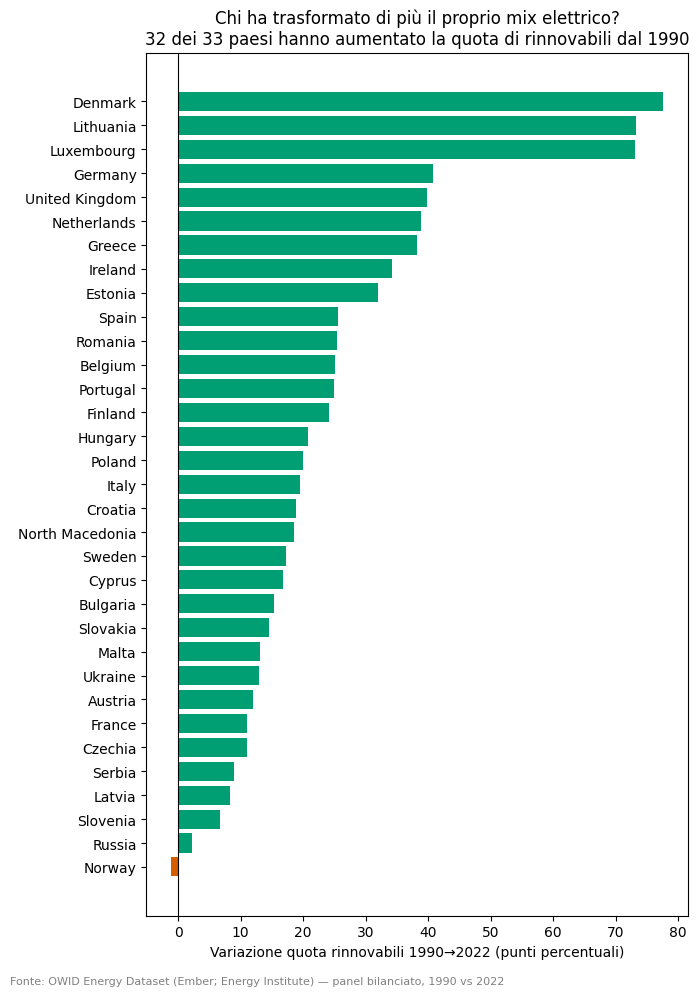

In [16]:
first_last = bal_all[bal_all["year"].isin([1990, 2022])].pivot(
    index="country", columns="year", values="renewables_share_elec"
)
delta = (first_last[2022] - first_last[1990]).sort_values()

colors = [PALETTE["calo"] if v < 0 else PALETTE["rinnovabili"] for v in delta]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(delta.index, delta.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Variazione quota rinnovabili 1990→2022 (punti percentuali)")
ax.set_title(
    f"Chi ha trasformato di più il proprio mix elettrico?\n"
    f"{(delta > 0).sum()} dei {len(delta)} paesi hanno aumentato la quota di rinnovabili dal 1990"
)
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 1990 vs 2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

Danimarca, Lituania e Lussemburgo guidano la classifica (+73–78 punti). L’unico caso in calo è la Norvegia (-1.1 punti): non è una regressione, è un effetto soffitto: era già al 99.8% nel 1990 (idroelettrico), non aveva margine per crescere. La Francia invece mostra una variazione modesta (+11 punti), ma non perché sia rimasta ferma: nel 1990 partiva già da un mix a basse emissioni grazie al nucleare, e la metrica "variazione quota rinnovabili" penalizza chi ha scelto una strada diversa (nucleare invece di rinnovabili) per arrivare allo stesso obiettivo di decarbonizzazione. Meglio dirlo chiaramente in dashboard, altrimenti il grafico fa sembrare che la Francia abbia fatto "poco", quando ha solo seguito un altro percorso.

### 4.4 Quanto veloce, non solo quanto: un indice di crescita (1990 = 100)

La applico alla produzione rinnovabile assoluta (TWh) di quattro paesi con basi di partenza molto diverse (Polonia, Danimarca, Germania, Italia), affiancata al valore assoluto per non perdere la scala reale.

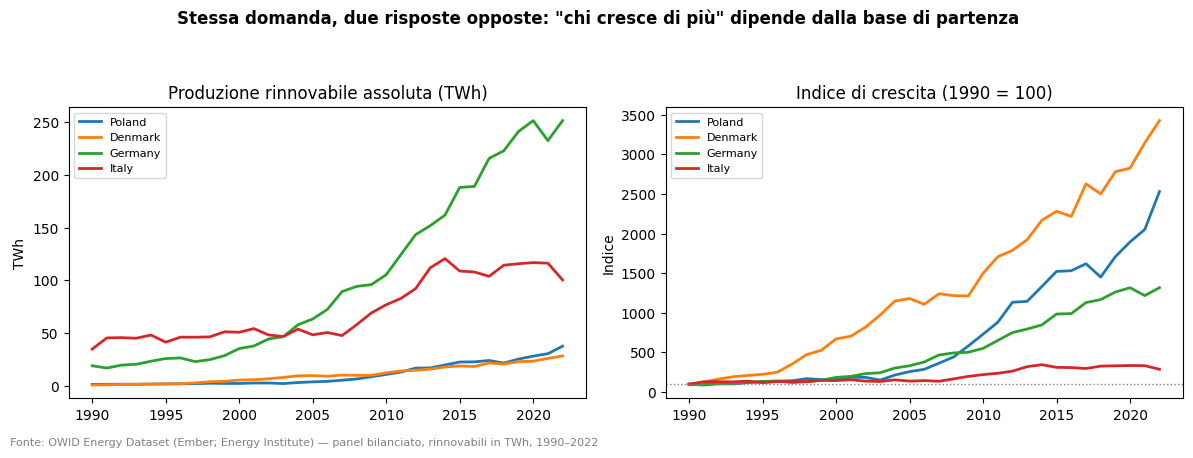

      Poland  Denmark  Germany  Italy
year                                 
1990   100.0    100.0    100.0  100.0
2000   156.0    671.0    185.0  146.0
2010   730.0   1498.0    552.0  221.0
2022  2530.0   3425.0   1317.0  288.0


In [17]:
growth_countries = ["Poland", "Denmark", "Germany", "Italy"]

idx_series = {}
for country in growth_countries:
    s = bal_all[bal_all["country"] == country].sort_values("year").set_index("year")["renewables_electricity"]
    idx_series[country] = s / s.loc[1990] * 100
idx_df = pd.DataFrame(idx_series)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for country in growth_countries:
    s = bal_all[bal_all["country"] == country].sort_values("year").set_index("year")["renewables_electricity"]
    axes[0].plot(s.index, s.values, label=country, linewidth=2)
axes[0].set_title("Produzione rinnovabile assoluta (TWh)")
axes[0].set_ylabel("TWh")
axes[0].legend(fontsize=8)

for country in growth_countries:
    axes[1].plot(idx_df.index, idx_df[country], label=country, linewidth=2)
axes[1].axhline(100, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Indice di crescita (1990 = 100)")
axes[1].set_ylabel("Indice")
axes[1].legend(fontsize=8)

fig.suptitle('Stessa domanda, due risposte opposte: "chi cresce di più" dipende dalla base di partenza', fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, rinnovabili in TWh, 1990–2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

print(idx_df.loc[[1990, 2000, 2010, 2022]].round(0))

Il pannello destro mostra il limite della tecnica quando le basi di partenza sono molto diverse. Danimarca partiva da 0.83 TWh di rinnovabili nel 1990 e Polonia da 1.49 TWh: basi quasi a zero che fanno esplodere l’indice (rispettivamente ~3425 e ~2530 nel 2022), pur avendo aggiunto molto meno in valore assoluto della Germania, che parte da una base già dieci volte più alta (19 TWh) e arriva comunque a un indice di ~1317, "solo" perché la sua base iniziale non era vicina allo zero. L’Italia, che partiva da una base già consistente (35 TWh, quasi il doppio della Germania), cresce in modo molto più lineare: indice ~288 nel 2022, il più basso dei quattro: non perché la crescita in TWh sia stata piccola (+65 TWh), ma perché la base di partenza era già alta. Il pannello sinistro (valori assoluti) infatti dice l’opposto: la Germania ha aggiunto ~232 TWh di rinnovabili tra il 1990 e il 2022, più dell’intera generazione elettrica danese di oggi. Nell’esempio del corso il price index funzionava bene da solo perché i prezzi di partenza delle città erano vicini (107–152 €, meno di un ordine di grandezza); qui invece l’indice va sempre affiancato al valore assoluto, mai da solo, altrimenti Danimarca e Polonia sembrano i casi più dinamici e l’Italia il più fermo, quando in TWh aggiunti il vero traino è la Germania e l’Italia non è affatto ferma.

### 4.5 Chi sostituisce chi: le rinnovabili al posto del fossile o del nucleare?

In Germania il nucleare è crollato dal 28% (1990) al 6.1% (2022) mentre le rinnovabili sono salite dal 3.5% al 44.4%: la domanda naturale è se dietro questo calo ci sia sempre lo stesso meccanismo — le rinnovabili che sostituiscono il nucleare — e se valga per tutto il panel o solo per questo paese. È un task di correlazione tra due variazioni: la Germania da sola è un aneddoto, i 33 paesi del panel permettono di controllare se il suo pattern è la regola o l’eccezione. Encoding di conseguenza: uno scatter (posizione su due assi), quello che secondo Cleveland & McGill rappresenta meglio una relazione tra due variabili continue.

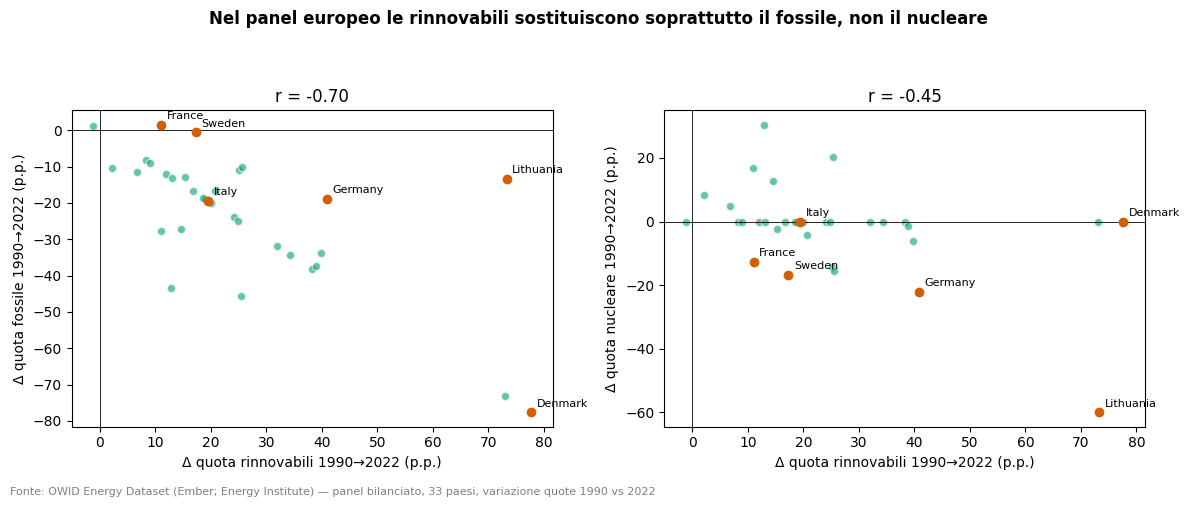

corr(Δrinnovabili, Δfossile)  = -0.70
corr(Δrinnovabili, Δnucleare) = -0.45


In [18]:
first_last_all = bal_all[bal_all["year"].isin([1990, 2022])].pivot_table(
    index="country", columns="year",
    values=["fossil_share_elec", "nuclear_share_elec", "renewables_share_elec"],
)
d_renew = first_last_all["renewables_share_elec"][2022] - first_last_all["renewables_share_elec"][1990]
d_fossil = first_last_all["fossil_share_elec"][2022] - first_last_all["fossil_share_elec"][1990]
d_nuclear = first_last_all["nuclear_share_elec"][2022] - first_last_all["nuclear_share_elec"][1990]

corr_fossil = d_renew.corr(d_fossil)
corr_nuclear = d_renew.corr(d_nuclear)

highlight = ["Germany", "Lithuania", "Denmark", "France", "Sweden", "Italy"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, d_other, label, corr in [
    (axes[0], d_fossil, "fossile", corr_fossil),
    (axes[1], d_nuclear, "nucleare", corr_nuclear),
]:
    ax.scatter(d_renew, d_other, color=PALETTE["rinnovabili"], alpha=0.6, edgecolor="white")
    for c in highlight:
        ax.scatter(d_renew[c], d_other[c], color=PALETTE["calo"], zorder=3)
        ax.annotate(c, (d_renew[c], d_other[c]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel("Δ quota rinnovabili 1990→2022 (p.p.)")
    ax.set_ylabel(f"Δ quota {label} 1990→2022 (p.p.)")
    ax.set_title(f"r = {corr:.2f}")

fig.suptitle("Nel panel europeo le rinnovabili sostituiscono soprattutto il fossile, non il nucleare", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 33 paesi, variazione quote 1990 vs 2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

print(f"corr(Δrinnovabili, Δfossile)  = {corr_fossil:.2f}")
print(f"corr(Δrinnovabili, Δnucleare) = {corr_nuclear:.2f}")

La correlazione conferma che il fossile è il bersaglio prevalente (r = -0.70), più del nucleare (r = -0.45): nella maggioranza dei 33 paesi il nucleare non c’è mai stato (quota 0 sia nel 1990 sia nel 2022, tra cui Danimarca, Grecia, Irlanda, Portogallo, Italia) o è rimasto stabile, e la crescita delle rinnovabili ha eroso quota fossile. L’Italia è un caso tipico di questo gruppo: +19.5 p.p. di rinnovabili, quasi esattamente speculare ai -19.5 p.p. di fossile, variazione nucleare nulla perché la fonte non c’è proprio. Un piccolo gruppo (Germania, Lituania, Svezia, e in misura minore Francia e Belgio) fa eccezione: qui un calo di nucleare coesiste con la crescita rinnovabile, per ragioni diverse caso per caso: la Lituania ha chiuso la centrale di Ignalina (eredità sovietica) come condizione per entrare nell’UE, la Svezia ha ridotto la sua flotta per scelta interna, la Germania è uscita dal nucleare dopo Fukushima (2011). Il pattern tedesco quindi non è un’anomalia isolata, ma nemmeno la norma: è uno dei pochi casi in cui è vero che "le rinnovabili hanno sostituito il nucleare": per la maggior parte degli altri paesi del panel, Italia compresa, a cedere terreno è il fossile, non il nucleare.

### 4.6 Il declino del nucleare: picco, evento, crollo

Il Cap. 4.5 ha isolato un piccolo gruppo di paesi dove il calo del nucleare coincide con la crescita rinnovabile: Germania, Lituania, Svezia, Francia e Belgio. Per ciascuno la domanda naturale è quando è iniziato il declino e perché, non solo quanto è cambiata la quota. È un task di confronto nel tempo con eventi noti: una linea per paese con un punto sul picco storico e un’annotazione sull’evento che ha innescato la discesa. Uso la serie estesa dal 1985 (non solo il panel bilanciato 1990-2022) perché per Belgio e Lituania il picco storico cade proprio a ridosso di quella soglia.

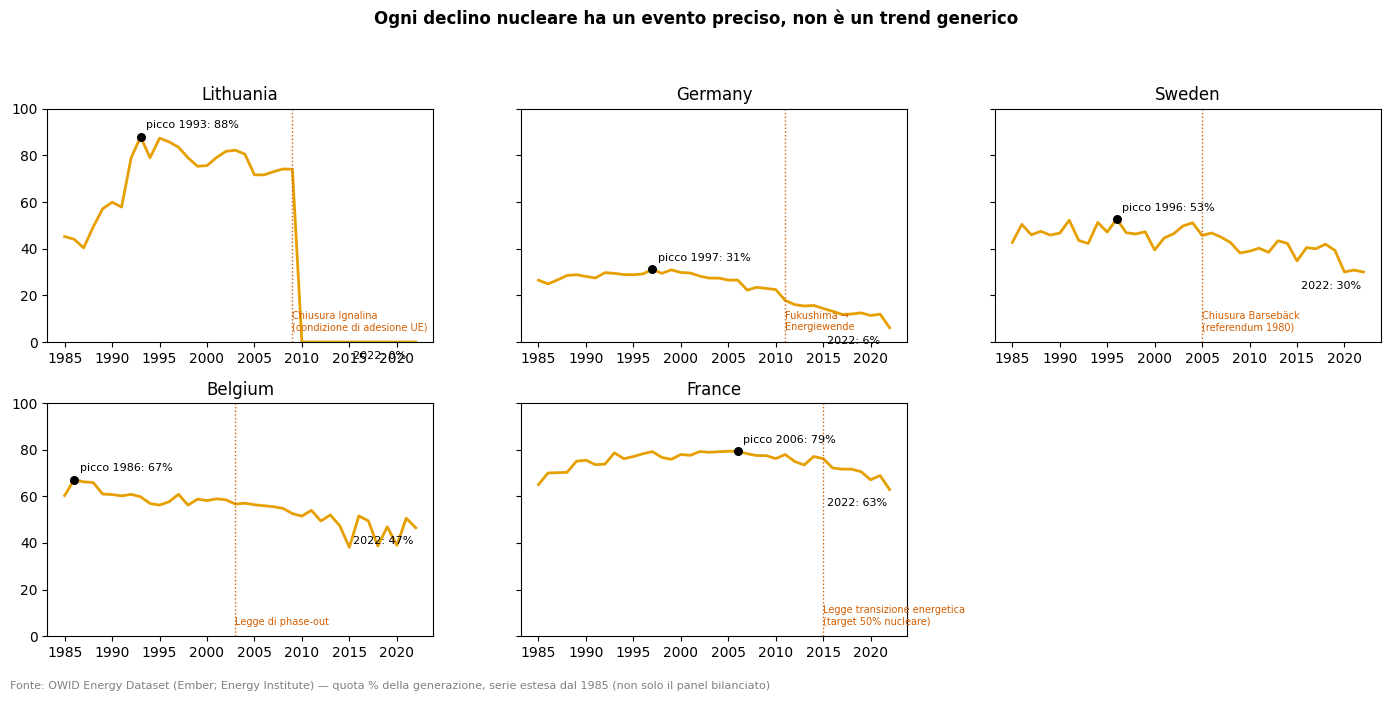

In [19]:
nuclear_countries = ["Lithuania", "Germany", "Sweden", "Belgium", "France"]
events = {
    "Lithuania": (2009, "Chiusura Ignalina\n(condizione di adesione UE)"),
    "Germany": (2011, "Fukushima →\nEnergiewende"),
    "Sweden": (2005, "Chiusura Barsebäck\n(referendum 1980)"),
    "Belgium": (2003, "Legge di phase-out"),
    "France": (2015, "Legge transizione energetica\n(target 50% nucleare)"),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, country in zip(axes.flat, nuclear_countries):
    s = df_eu[df_eu["country"] == country].sort_values("year").set_index("year")["nuclear_share_elec"].dropna()
    s = s[s.index <= 2022]
    peak_year = s.idxmax()
    ax.plot(s.index, s.values, color=PALETTE["nucleare"], linewidth=2)
    ax.scatter([peak_year], [s[peak_year]], color="black", zorder=3, s=30)
    ax.annotate(f"picco {peak_year}: {s[peak_year]:.0f}%", (peak_year, s[peak_year]),
                fontsize=8, xytext=(4, 6), textcoords="offset points")
    ev_year, ev_label = events[country]
    ax.axvline(ev_year, color=PALETTE["calo"], linestyle=":", linewidth=1)
    ax.annotate(ev_label, (ev_year, 5), fontsize=7, color=PALETTE["calo"])
    ax.annotate(f"2022: {s.loc[2022]:.0f}%", (2022, s.loc[2022]), fontsize=8,
                xytext=(-45, -12), textcoords="offset points")
    ax.set_title(country)
    ax.set_ylim(0, 100)
axes.flat[-1].axis("off")
fig.suptitle("Ogni declino nucleare ha un evento preciso, non è un trend generico", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — quota % della generazione, serie estesa dal 1985 (non solo il panel bilanciato)", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

Il picco e l’evento non coincidono mai: la Lituania tocca l’88% nel 1993 (Ignalina, eredità sovietica, unica centrale del paese) ma il declino a zero arriva solo dopo la chiusura definitiva del secondo reattore nel 2009, imposta come condizione di adesione all’UE, sedici anni dopo il picco. La Germania picca al 31.2% nel 1997, ben prima di Fukushima (2011): l’uscita dal nucleare non è la causa del declino ma la sua accelerazione: l’ultimo reattore si è fermato nell’aprile 2023, pochi mesi dopo il 2022 con cui chiudo questo pannello. Svezia e Belgio hanno il pattern più lento: entrambi i declini seguono leggi di phase-out (Svezia dopo il referendum del 1980, chiusure Barsebäck nel 1999 e 2005; Belgio con la legge del 2003) ma restano rispettivamente al 30% e al 46.5% ancora nel 2022: un phase-out annunciato non è un crollo immediato. La Francia è il caso più lento di tutti: picca nel 2006 (79.4%) e nel 2022 è ancora al 62.9%, nonostante la legge del 2015 avesse fissato un obiettivo del 50% mai raggiunto: il calo del 2022 è dovuto a un evento congiunturale (corrosione, siccità), non alla legge.

### 4.7 Perché non un radar chart

I mix energetici fanno venire voglia di un confronto multi-dimensionale (fossile, nucleare, idro, eolico, solare, altre rinnovabili). Lo provo su cinque paesi con strategie di mix molto diverse (Francia, Germania, Polonia, Danimarca, Italia): la tentazione è un radar chart, un poligono per paese.

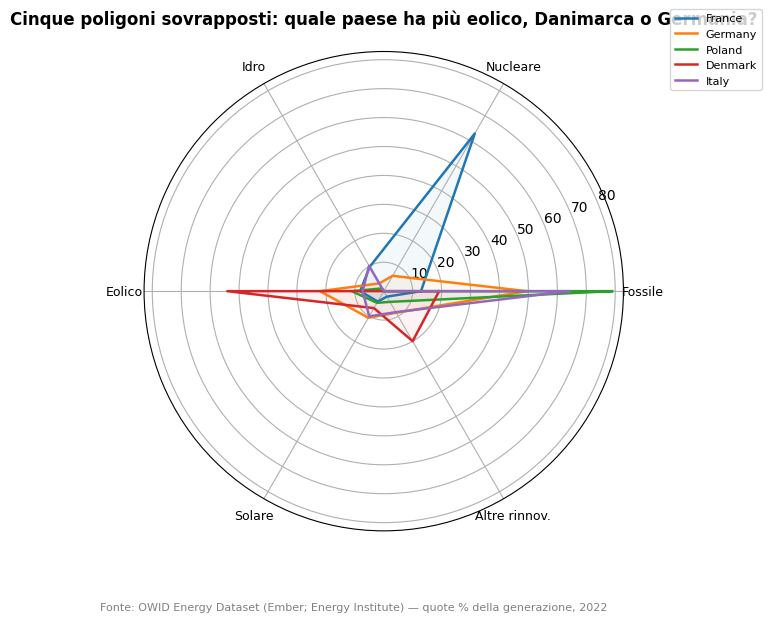

In [20]:
import numpy as np

radar_countries = ["France", "Germany", "Poland", "Denmark", "Italy"]

radar_cols = ["fossil_share_elec", "nuclear_share_elec", "hydro_share_elec",
              "wind_share_elec", "solar_share_elec", "other_renewables_share_elec"]
radar_labels = ["Fossile", "Nucleare", "Idro", "Eolico", "Solare", "Altre rinnov."]

d2022 = df[(df["country"].isin(radar_countries)) & (df["year"] == 2022)].set_index("country")[radar_cols]

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
for country in radar_countries:
    values = d2022.loc[country].tolist()
    values += values[:1]
    ax.plot(angles, values, label=country, linewidth=1.8)
    ax.fill(angles, values, alpha=0.05)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_title("Cinque poligoni sovrapposti: quale paese ha più eolico, Danimarca o Germania?", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — quote % della generazione, 2022", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

Il radar sovrappone sei poligoni irregolari e costringe a confrontare angoli e aree invece che posizioni su un asse comune: l’encoding meno accurato nella gerarchia di Cleveland & McGill. Rispondere a una domanda semplice come "chi ha più eolico, Danimarca o Germania?" richiede di confrontare due segmenti radiali che partono da angoli diversi, impossibile a colpo d’occhio. Il radar aggiunge anche una distorsione tutta sua: l’area di un poligono cresce più che linearmente con i valori sui suoi assi, quindi un paese con valori medi su tutti gli assi può sembrare visivamente "più grande" di un paese con un solo valore dominante, a parità di informazione trasmessa. Non lo uso in dashboard: per un confronto multi-variabile tra pochi paesi restano meglio degli stacked bar al 100% affiancati.